# Notebook 5A — Practical: Repeated-measures ANOVA with IBL behaviour

**Quantitative Methods in Neuroscience · Master in Neuroscience · University of Geneva**  
**Responsible TA:** Caroline · **Contributing TA:** Maël

This is the **essential practical notebook**. It deliberately keeps the mathematics light and focuses on the analysis decisions students must make in a real repeated-measures experiment.

## By the end of the practical, you will be able to

1. identify the outcome, within-subject factor, and subject identifier;
2. transform trial-level data into one observation per mouse and condition;
3. visualize distributions while preserving the paired structure;
4. fit and interpret a repeated-measures ANOVA;
5. perform paired follow-up comparisons with Holm correction;
6. produce a final boxplot with corrected significance brackets;
7. write a concise scientific result.

## Suggested two-hour structure

| Time | Activity |
|---|---|
| 0–15 min | Scientific question and data structure |
| 15–40 min | Cleaning and grouping |
| 40–65 min | Boxplot and paired visualization |
| 65–95 min | Repeated-measures ANOVA |
| 95–115 min | Follow-up comparisons |
| 115–120 min | Write the result |

Difficulty tags follow the course convention: ⭐ essential, ⭐⭐ short extension, ⭐⭐⭐ optional challenge.


## 0 · Setup

Use the shared **Python (qmn)** kernel created in Week 1.

The IBL dataset was already prepared at the beginning of the course and is stored in:

```text
notebooks/data/ibl_2afc.csv.gz
```

Place this Week 5 notebook inside the course `notebooks/` folder, alongside Notebooks 1 and 2. The notebook does **not** install packages, contact OpenAlyx, or download the IBL data again.


In [1]:
from pathlib import Path
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_columns", 50)

# Same relative-path convention used by the earlier course notebooks.
DATA_PATH = Path("data") / "ibl_2afc.csv.gz"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Could not find data/ibl_2afc.csv.gz. "
        "Open this notebook from the QMN course notebooks/ folder and check "
        "that the Week 1 course data were downloaded or copied correctly."
    )

print("Using the shared course dataset:", DATA_PATH.resolve())


Using the shared course dataset: /home/carolinealves/Documents/QMN-subject/QMN_course_2026_with_Week5_v2/QMN_course_2026-main/notebooks/data/ibl_2afc.csv.gz


## 1 · Scientific question

Mice performed a visual decision-making task at several stimulus contrasts. Stronger contrast provides clearer visual evidence.

> **Question:** Does mean reaction time differ across low, medium, and high stimulus contrast when the same mice are measured in every condition?

The variables are:

| Statistical role | Dataset column |
|---|---|
| Subject identifier | `subject_id` |
| Within-subject factor | `contrast_level` |
| Dependent variable | mean `reaction_time_s` |

Because every mouse contributes to every contrast condition, the observations are paired by mouse.


### Exercise 1 — ⭐

Before running code, answer in one sentence: why would an analysis that treats all trials as independent overstate the amount of independent information?


In [2]:
# Write your answer as a Python string.
answer_exercise_1 = ''
print(answer_exercise_1)


## 2 · Load and inspect the shared IBL course data

This is the **same full IBL behavioural dataset used across the course**, not a Week 5-specific copy. To keep memory use modest, we load only the columns required for this practical.

The file remains trial-level at this stage. Later, we will create one value per mouse and contrast condition for the repeated-measures analysis.


In [3]:
# Load only the variables needed for the Week 5 question.
columns_needed = [
    "subject_id",
    "phase",
    "signed_contrast",
    "no_go",
    "reaction_time_s",
    "correct",
]

trials = pd.read_csv(DATA_PATH, usecols=columns_needed)

print("Rows, columns loaded:", trials.shape)
print("Mice:", trials["subject_id"].nunique())
display(trials.head())


Rows, columns loaded: (694182, 6)
Mice: 30


,subject_id,phase,signed_contrast,correct,no_go,reaction_time_s
0,CSHL051,training,0.5,1.0,False,NaN
1,CSHL051,training,1.0,0.0,False,5.1798
2,CSHL051,training,1.0,0.0,False,7.4795
3,CSHL051,training,-1.0,0.0,False,0.0693
4,CSHL051,training,-1.0,1.0,False,18.5863


### Exercise 2 — ⭐

Use `.isna().sum()` to inspect missing values. Which columns require attention before analysing reaction time?


In [4]:
# TODO: inspect missing values.
# missing_values = ...
# display(...)

## 3 · Prepare the repeated-measures table

We apply four pre-specified rules:

1. use trained sessions;
2. remove no-go trials and missing reaction times;
3. retain reaction times from 0.08 to 2.00 seconds, following the validity window documented in the supplied course data dictionary;
4. group non-zero absolute contrast into low (6.25–12.5%), medium (25–50%), and high (100%).

The inferential table must contain **one mean per mouse and contrast condition**.


In [5]:
def prepare_repeated_measures_table(trials):
    """Return cleaned trials and one mean RT per mouse and contrast level."""
    analysis = trials.loc[
        trials["phase"].eq("trained") &
        (~trials["no_go"]) &
        trials["reaction_time_s"].notna()
    ].copy()

    # Course-wide validity rule from the supplied data dictionary.
    analysis = analysis[analysis["reaction_time_s"].between(0.08, 2.0)]

    analysis["contrast_abs"] = analysis["signed_contrast"].abs()
    analysis = analysis[analysis["contrast_abs"] > 0].copy()

    conditions = [
        analysis["contrast_abs"] <= 0.125,
        analysis["contrast_abs"] <= 0.5,
        analysis["contrast_abs"] == 1.0,
    ]
    labels = ["low", "medium", "high"]
    analysis["contrast_level"] = np.select(conditions, labels, default=None)
    analysis = analysis.dropna(subset=["contrast_level"])

    order = ["low", "medium", "high"]
    analysis["contrast_level"] = pd.Categorical(
        analysis["contrast_level"], categories=order, ordered=True
    )

    subject_means = (
        analysis.groupby(["subject_id", "contrast_level"], observed=True)
        .agg(
            mean_rt_s=("reaction_time_s", "mean"),
            accuracy=("correct", "mean"),
            n_trials=("reaction_time_s", "size"),
        )
        .reset_index()
    )

    # AnovaRM requires a complete subject × condition table.
    complete = (
        subject_means.groupby("subject_id", observed=True)["contrast_level"]
        .nunique()
        .loc[lambda s: s == len(order)]
        .index
    )
    subject_means = subject_means[subject_means["subject_id"].isin(complete)].copy()
    return analysis, subject_means, order


In [6]:
clean_trials, subject_means, order = prepare_repeated_measures_table(trials)

print("Clean trials:", clean_trials.shape)
print("ANOVA rows:", subject_means.shape)
print("Complete mice:", subject_means["subject_id"].nunique())
display(subject_means.head(9))


Clean trials: (77426, 8)
ANOVA rows: (90, 5)
Complete mice: 30


,subject_id,contrast_level,mean_rt_s,accuracy,n_trials
0,CSHL045,low,0.405504,0.817888,1856
1,CSHL045,medium,0.223112,0.954076,871
2,CSHL045,high,0.182417,0.988119,505
3,CSHL046,low,0.489543,0.791304,1495
4,CSHL046,medium,0.311712,0.932584,712
5,CSHL046,high,0.247756,0.959243,687
6,CSHL047,low,0.357088,0.667500,400
7,CSHL047,medium,0.202142,0.915663,166
8,CSHL047,high,0.157890,0.963235,136


### Exercise 3 — ⭐⭐

Create a table containing the mean, standard deviation, and number of mice for each contrast level.


In [7]:
# TODO: group subject_means by contrast_level and calculate
# mean, standard deviation, and count for mean_rt_s.
# condition_summary = ...

## 4 · Visualize the distributions and the pairing

The **boxplots** summarize the distribution of mouse-level mean reaction times in each condition. Because this is a repeated-measures design, we also connect the three measurements belonging to the same mouse.

This combination shows both:

- the distribution within each contrast condition; and
- the direction of change within individual mice.


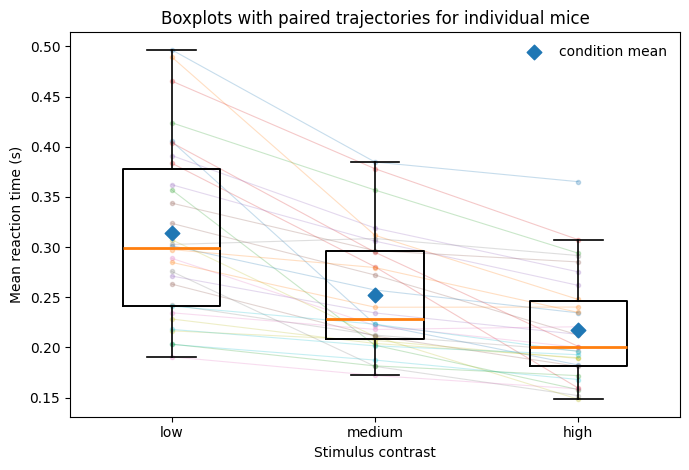

In [8]:
wide = (
    subject_means.pivot(index="subject_id", columns="contrast_level", values="mean_rt_s")
    .reindex(columns=order)
)

positions = np.arange(len(order))
fig, ax = plt.subplots(figsize=(7, 4.8))

# Repeated-measures structure: one connected trajectory per mouse.
for _, row in wide.iterrows():
    ax.plot(
        positions, row.values,
        marker="o", markersize=3, linewidth=0.8, alpha=0.25, zorder=1
    )

# Distribution of mouse-level means in each condition.
ax.boxplot(
    [wide[level].dropna().values for level in order],
    positions=positions, widths=0.48, showfliers=False,
    medianprops={"linewidth": 2},
    boxprops={"linewidth": 1.4},
    whiskerprops={"linewidth": 1.2},
    capprops={"linewidth": 1.2},
)

# Add the arithmetic mean as a diamond.
condition_mean = wide.mean()
ax.scatter(positions, condition_mean.values, marker="D", s=55,
           label="condition mean", zorder=4)

ax.set_xticks(positions, order)
ax.set(
    xlabel="Stimulus contrast",
    ylabel="Mean reaction time (s)",
    title="Boxplots with paired trajectories for individual mice",
)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


### Interpretation checkpoint — ⭐

Do most mouse trajectories rise, fall, or show no consistent direction as contrast increases? This descriptive pattern should be stated before looking at the p-value.


In [9]:
trajectory_interpretation = ''
print(trajectory_interpretation)


## 5 · Fit the repeated-measures ANOVA

The model tests whether the three condition means are equal while preserving mouse identity. For this practical, use the standard `AnovaRM` implementation rather than calculating sums of squares manually.


In [10]:
aov = AnovaRM(
    data=subject_means,
    depvar="mean_rt_s",
    subject="subject_id",
    within=["contrast_level"],
).fit()

print(aov)
anova_table = aov.anova_table.copy()
display(anova_table)


                   Anova
               F Value Num DF  Den DF Pr > F
--------------------------------------------
contrast_level 53.1302 2.0000 58.0000 0.0000



,F Value,Num DF,Den DF,Pr > F
contrast_level,53.130217,2.0,58.0,7.743831e-14


The ANOVA p-value answers whether at least one condition differs. It does not identify which pairs differ.

We also calculate partial eta-squared as a compact effect-size summary from the reported F statistic and degrees of freedom.


In [11]:
row = anova_table.loc["contrast_level"]
F_value = float(row["F Value"])
df_effect = float(row["Num DF"])
df_error = float(row["Den DF"])
p_anova = float(row["Pr > F"])
partial_eta_squared = (F_value * df_effect) / (F_value * df_effect + df_error)

print(f"F({df_effect:.0f}, {df_error:.0f}) = {F_value:.2f}")
print(f"p = {p_anova:.3g}")
print(f"partial eta-squared = {partial_eta_squared:.3f}")


F(2, 58) = 53.13
p = 7.74e-14
partial eta-squared = 0.647


### Exercise 4 — ⭐

Complete the decision without relying only on the word “significant”:

- Is there evidence that reaction time differs across contrast levels?
- In which direction do the descriptive means change?


In [12]:
anova_interpretation = ''
print(anova_interpretation)


## 6 · Paired follow-up comparisons

Because the factor is within-subject, follow-up comparisons are paired tests on mouse-level means. Holm correction controls the family-wise error rate across the three comparisons.


In [13]:
def paired_followups(wide_table, order):
    """Paired t-tests with Holm correction, paired effect size, and 95% CI."""
    rows = []
    for first, second in itertools.combinations(order, 2):
        difference = wide_table[first] - wide_table[second]
        test = stats.ttest_rel(wide_table[first], wide_table[second])
        n = difference.notna().sum()
        mean_difference = difference.mean()
        se_difference = difference.sem()
        t_critical = stats.t.ppf(0.975, df=n - 1)
        ci_low = mean_difference - t_critical * se_difference
        ci_high = mean_difference + t_critical * se_difference
        cohen_dz = mean_difference / difference.std(ddof=1)
        rows.append({
            "comparison": f"{first} - {second}",
            "mean_difference_s": mean_difference,
            "ci95_low_s": ci_low,
            "ci95_high_s": ci_high,
            "t": test.statistic,
            "df": n - 1,
            "p_raw": test.pvalue,
            "cohen_dz": cohen_dz,
        })

    results = pd.DataFrame(rows)
    results["p_holm"] = multipletests(results["p_raw"], method="holm")[1]
    results["reject_holm_0.05"] = results["p_holm"] < 0.05
    return results


In [14]:
followups = paired_followups(wide, order)
display(
    followups.style.format({
        "mean_difference_s": "{:.4f}",
        "ci95_low_s": "{:.4f}",
        "ci95_high_s": "{:.4f}",
        "t": "{:.2f}",
        "p_raw": "{:.3g}",
        "p_holm": "{:.3g}",
        "cohen_dz": "{:.2f}",
    })
)


,comparison,mean_difference_s,ci95_low_s,ci95_high_s,t,df,p_raw,cohen_dz,p_holm,reject_holm_0.05
0,low - medium,0.0614,0.0428,0.0799,6.78,29,1.92e-07,1.24,3.66e-07,True
1,low - high,0.0963,0.0704,0.1222,7.61,29,2.16e-08,1.39,6.49e-08,True
2,medium - high,0.0350,0.0245,0.0455,6.80,29,1.83e-07,1.24,3.66e-07,True


### Exercise 5 — ⭐⭐

Which comparison has the largest absolute mean difference? Use the results table rather than guessing from the p-values.


In [15]:
# TODO: create an absolute-difference column, sort it,
# and retrieve the comparison in the first row.
# largest_difference = ...

## 7 · Final result figure: boxplot with corrected significance stars

The first boxplot was deliberately descriptive: it showed the distributions and the paired mouse trajectories **before** statistical testing. After the repeated-measures ANOVA and paired follow-up tests, we can now produce the final inferential figure.

This version follows the style of the original Week 5 example:

- white boxplots summarize the mouse-level distributions;
- points represent individual mice;
- grey lines preserve the repeated-measures pairing;
- the line and error bars show the group mean ± SEM;
- brackets and stars show the **Holm-corrected paired comparisons**.

The stars must never be added from uncorrected p-values when several pairwise tests belong to the same family.


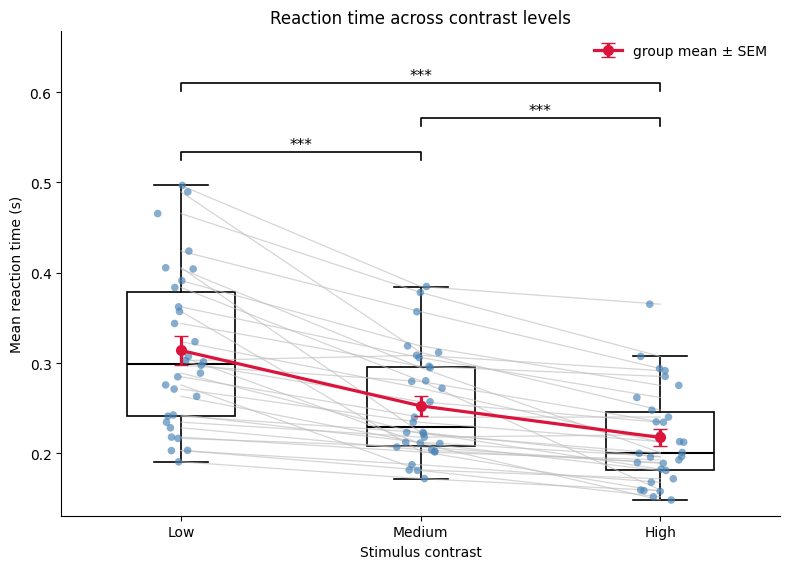

In [16]:
def p_to_stars(p_value):
    """Convert a corrected p-value to the conventional star label."""
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "ns"


def add_significance_bracket(ax, x1, x2, y, height, label):
    """Draw one comparison bracket and its label."""
    ax.plot([x1, x1, x2, x2], [y, y + height, y + height, y],
            linewidth=1.2, color="black", clip_on=False)
    ax.text((x1 + x2) / 2, y + height, label,
            ha="center", va="bottom", fontsize=11)


# Put the shorter adjacent comparisons first and the widest comparison last.
plot_pairs = [("low", "medium"), ("medium", "high"), ("low", "high")]
p_holm_lookup = dict(zip(followups["comparison"], followups["p_holm"]))

positions = np.arange(len(order))
means = wide.mean().reindex(order)
sems = wide.sem().reindex(order)

fig, ax = plt.subplots(figsize=(8, 5.8))

# Traditional boxplots of the per-mouse means.
box = ax.boxplot(
    [wide[level].dropna().values for level in order],
    positions=positions,
    widths=0.45,
    showfliers=False,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 1.5},
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 1.2},
    whiskerprops={"color": "black", "linewidth": 1.2},
    capprops={"color": "black", "linewidth": 1.2},
    zorder=1,
)

# Same mouse across all three conditions.
for _, row in wide.iterrows():
    ax.plot(positions, row[order].values,
            color="0.75", alpha=0.65, linewidth=0.9, zorder=2)

# Slight deterministic jitter keeps overlapping points visible.
rng = np.random.default_rng(2026)
for x, level in enumerate(order):
    values = wide[level].dropna().to_numpy()
    jitter = rng.uniform(-0.10, 0.10, size=len(values))
    ax.scatter(np.full(len(values), x) + jitter, values,
               s=30, alpha=0.65, color="steelblue", edgecolors="none", zorder=3)

# Group mean ± SEM.
ax.errorbar(
    positions, means.values, yerr=sems.values,
    fmt="o-", color="crimson", linewidth=2.3,
    capsize=5, markersize=7, label="group mean ± SEM", zorder=4,
)

# Holm-corrected pairwise significance brackets.
y_min = float(np.nanmin(wide.to_numpy()))
y_max = float(np.nanmax(wide.to_numpy()))
y_range = max(y_max - y_min, 0.05)
base = y_max + 0.08 * y_range
step = 0.11 * y_range
height = 0.025 * y_range
x_lookup = {level: i for i, level in enumerate(order)}

for bracket_index, (first, second) in enumerate(plot_pairs):
    key = f"{first} - {second}"
    corrected_p = float(p_holm_lookup[key])
    add_significance_bracket(
        ax,
        x_lookup[first], x_lookup[second],
        base + bracket_index * step,
        height,
        p_to_stars(corrected_p),
    )

ax.set_xticks(positions, [level.capitalize() for level in order])
ax.set(
    xlabel="Stimulus contrast",
    ylabel="Mean reaction time (s)",
    title="Reaction time across contrast levels",
)
ax.set_ylim(y_min - 0.05 * y_range,
            base + len(plot_pairs) * step + 0.08 * y_range)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()


**How to read the final figure**

- Blue points are the mouse-level mean reaction times.
- Grey lines connect repeated observations from the same mouse.
- The red line shows the group mean ± SEM.
- Brackets summarize paired tests after Holm correction.
- `*` means corrected *p* < .05, `**` means corrected *p* < .01, `***` means corrected *p* < .001, and `ns` means not significant.

The figure is a summary of the inferential results; the numerical ANOVA and follow-up table remain the primary statistical report.


## 8 · Write the scientific result

A useful result reports the design, test, direction, effect size, and corrected follow-ups. Avoid reporting only “p < 0.05”.

### Reporting template

> A one-factor repeated-measures ANOVA tested whether mean reaction time differed across low, medium, and high stimulus contrast. Reaction time [direction based on means]. The effect of contrast was [test result], *F*(*df*1, *df*2) = ..., *p* = ..., partial η² = .... Holm-corrected paired comparisons showed that ....


In [17]:
result_sentence = 'Write your result here.'
print(result_sentence)


Write your result here.


## 9 · Optional extension — ⭐⭐⭐

Repeat the same workflow using `accuracy` instead of `mean_rt_s`. Treat this only as a teaching extension: accuracy is a proportion derived from binary trials, and trial-level generalized mixed models are preferable when the course reaches more advanced modelling.


## Take-home message

The central practical decision is not the function name. It is recognizing that the mouse is the experimental unit and that the same mouse is observed repeatedly. Prepare one value per mouse and condition, visualize the pairing, fit the repeated-measures model, and use paired corrected follow-ups.

## Data reference

The shared course data were derived from the public International Brain Laboratory behavioural release described in **“Standardized and reproducible measurement of decision-making in mice”** (International Brain Laboratory et al., 2021, *eLife*).
